# Standard problem 3

## Problem specification

This problem is to calculate a single domain limit of a cubic magnetic particle. This is the size $L$ of equal energy for the so-called flower state (which one may also call a splayed state or a modified single-domain state) on the one hand, and the vortex or curling state on the other hand.

Geometry:

A cube with edge length, $L$, expressed in units of the intrinsic length scale, $l_\text{ex} = \sqrt{A/K_\text{m}}$, where $K_\text{m}$ is a magnetostatic energy density, $K_\text{m} = \frac{1}{2}\mu_{0}M_\text{s}^{2}$.

Material parameters: 

- uniaxial anisotropy $K_\text{u}$ with $K_\text{u} = 0.1 K_\text{m}$, and with the easy axis directed parallel to a principal axis of the cube (0, 0, 1),
- exchange energy constant is $A = \frac{1}{2}\mu_{0}M_\text{s}^{2}l_\text{ex}^{2}$.

More details about the standard problem 3 can be found in Ref. 1.

## Simulation

Firstly, we import all necessary modules.

In [1]:
import numpy as np
from scipy import constants

import neuralmag as nm

2025-03-26 23:54:23 NeuralMag:INFO [NeuralMag] Version 0.9.1


The following two functions are used for initialising the system's magnetisation [1].

In [2]:
# Function for initiaising the flower state.
def m_init_flower(state):
    return nm.VectorFunction(state).fill((0.0, 0.0, 1))


# Function for initialising the vortex state.
def m_init_vortex(state):
    x, y, z = state.coordinates(spaces="nnn", numpy=True)
    out = np.stack([z, z - 50e-9, 50e-9 - y], axis=-1)
    norm = np.linalg.norm(out, axis=-1, keepdims=True)
    return nm.VectorFunction(state, tensor=state.tensor(out / norm))

The following function is used for convenience. It takes two arguments:

- $L$ - the cube edge length in units of $l_\text{ex}$, and
- the function for initialising the system's magnetization.

It returns the relaxed system object.

Please refer to other tutorials for more details on how to create system objects and drive them using specific drivers.

In [3]:
def minimise_system_energy(L, m_init):
    N = 10  # discretisation in one dimension
    Ms = 8e5  # saturation magnetization
    A = 13e-12  # exchange constant
    Km = constants.mu_0 * Ms**2 / 2.0  # effective anisotropy
    lex = (A / Km) ** 0.5  # exchange length
    dx = L * lex / N

    mesh = nm.Mesh((N, N, N), (dx, dx, dx))
    state = nm.State(mesh)

    state.material.Ms = Ms
    state.material.A = A
    state.material.alpha = 0.5
    state.material.Ku = 0.1 * Km
    state.material.Ku_axis = [0, 0, 1]

    state.m = m_init(state)

    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag", "aniso").register(state)

    # relax the system
    llg = nm.LLGSolver(state)
    llg.relax()
    return state

### Relaxed magnetization states

**Vortex** state:

In [4]:
state = minimise_system_energy(8, m_init_vortex)

2025-03-26 23:54:23 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2025-03-26 23:54:24 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-03-26 23:54:24 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-03-26 23:54:24 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-03-26 23:54:24 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)
2025-03-26 23:54:24 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-03-26 23:54:24 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-03-26 23:54:24 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-03-26 23:54:24 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-03-26 23:54:26 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-03-26 23:54:26 NeuralMag:INFO [LLGS

**Flower** state:

In [5]:
state = minimise_system_energy(8, m_init_flower)

2025-03-26 23:55:52 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2025-03-26 23:55:52 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-03-26 23:55:52 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)
2025-03-26 23:55:52 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-03-26 23:55:52 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-03-26 23:55:52 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-03-26 23:55:52 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-03-26 23:55:53 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-03-26 23:55:53 NeuralMag:INFO [LLGSolver] Initialize RHS function
2025-03-26 23:55:59 NeuralMag:INFO [LLGSolverJAX] Start relaxation, initial energy E = 8.83041e-18 J
2025-03-26 23:57

### Energy crossing

We can plot the energies of both vortex and flower states as a function of cube edge length $L$. This will give us an idea where the state transition occurrs. We can achieve that by simply looping over the edge lengths $L$ of interest, computing the energy of both vortex and flower states, and finally, plotting the energy dependence.

2025-03-26 23:57:24 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-09 x 4.77607e-09)
2025-03-26 23:57:24 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-03-26 23:57:24 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)
2025-03-26 23:57:24 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-03-26 23:57:24 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-03-26 23:57:24 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-03-26 23:57:24 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-03-26 23:57:25 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-03-26 23:57:25 NeuralMag:INFO [LLGSolver] Initialize RHS function
2025-03-26 23:57:32 NeuralMag:INFO [LLGSolverJAX] Start relaxation, initial energy E = 1.30246e-17 J
2025-03-26 23:58

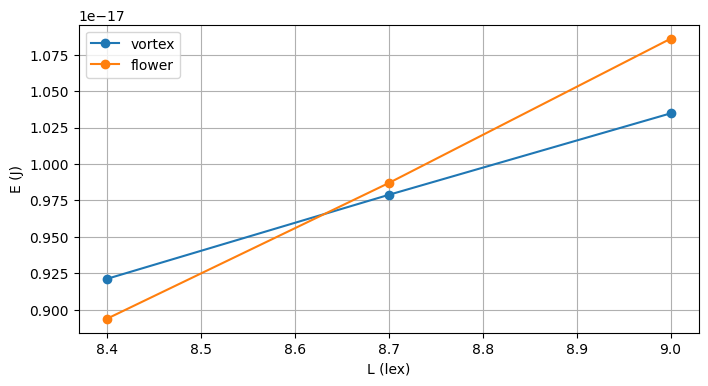

In [6]:
L_array = np.linspace(8.4, 9, 3)
vortex_energies, flower_energies = [], []
for L in L_array:
    vortex = minimise_system_energy(L, m_init_vortex)
    flower = minimise_system_energy(L, m_init_flower)
    vortex_energies.append(vortex.E)
    flower_energies.append(flower.E)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(L_array, vortex_energies, "o-", label="vortex")
plt.plot(L_array, flower_energies, "o-", label="flower")
plt.xlabel("L (lex)")
plt.ylabel("E (J)")
plt.grid()
plt.legend();

From the plot, we can see that the energy crossing occurrs between $8.4l_\text{ex}$ and $8.6l_\text{ex}$.

## References

[1] µMAG Site Directory http://www.ctcms.nist.gov/~rdm/mumag.org.

This tutorial was adapted from [Ubermag](https://ubermag.github.io/).